# BiLSTM Training + Evaluation 
Train/Val: P1_boning + P1_slicing | Test: P2_boning + P2_slicing

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('d:/Swin documents/COS40007-Project/backend')

# Importing libraries

In [2]:
from types import SimpleNamespace
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from utils.seed import set_seed
from utils.device import get_device
from data.preprocessing import (
    get_feature_columns,
    create_windows,
    clean_features,
    normalize_features,
)
from data.motion_dataset import MotionDataset
from model.bilstm import BiLSTM
from training.loss import build_loss
from training.trainer import train_epoch, eval_epoch

# Config (no Hydra)
seed = 42
device = get_device("auto")
set_seed(seed)

sensor_type = "Segment Velocity"
video_suffix = None
window_size = 60
stride = 30
batch_size = 32
num_workers = 0
val_split = 0.2

# P1 used for train/val; P2 used for test

hidden_size = 128
num_layers = 2
epochs = 30
lr = 1e-4
weight_decay = 1e-5
grad_clip = 1.0

loss_cfg = SimpleNamespace(type="auto")


# Read data 

In [4]:
print("[phase=data] loading P1 + P2 datasets")
DATA_DIR = PROJECT_ROOT / "output_data"

# P1 train/val
p1_dfs = [
    pd.read_csv(DATA_DIR / "P1_boning.csv"),
    pd.read_csv(DATA_DIR / "P1_slicing.csv"),
]
p1_df = pd.concat(p1_dfs, ignore_index=True)

# P2 test
p2_dfs = [
    pd.read_csv(DATA_DIR / "P2_boning.csv"),
    pd.read_csv(DATA_DIR / "P2_slicing.csv"),
]
p2_df = pd.concat(p2_dfs, ignore_index=True)

# Filter sensor
p1_df = p1_df[p1_df["sensor_type"] == sensor_type]
p2_df = p2_df[p2_df["sensor_type"] == sensor_type]

# Optional video suffix filter
if video_suffix is not None:
    p1_df = p1_df[p1_df["video_id"].str.endswith(video_suffix)]
    p2_df = p2_df[p2_df["video_id"].str.endswith(video_suffix)]

assert p1_df["activity_type"].nunique() > 1, "Only one class left after filtering - train/val invalid"
assert p2_df["activity_type"].nunique() > 1, "Only one class left after filtering - test invalid"

print(f"[phase=data] p1_rows={len(p1_df)} p2_rows={len(p2_df)}")
p1_df.head()


[phase=data] loading P1 + P2 datasets
[phase=data] p1_rows=266924 p2_rows=263369


,Frame,Pelvis x,Pelvis y,Pelvis z,L5 x,L5 y,L5 z,L3 x,L3 y,L3 z,...,Left Foot z,Left Toe x,Left Toe y,Left Toe z,Label,person_id,activity_type,knife_sharpness_score,sensor_type,video_id
0,0,0,0,0,0.016263,-0.095142,0.221275,0.016263,-0.095142,0.221275,...,-0.008848,-0.051999,-0.007358,-0.008848,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
1,1,0,0,0,0.001253,-0.126477,0.188341,-0.007620,-0.133955,0.187839,...,-0.039315,-0.063777,-0.030254,-0.039315,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
2,2,0,0,0,-0.013758,-0.157811,0.155406,-0.031503,-0.172767,0.154402,...,-0.069782,-0.075555,-0.053150,-0.069782,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
3,3,0,0,0,-0.022041,-0.178102,0.134543,-0.045098,-0.198298,0.133187,...,-0.088753,-0.082192,-0.067862,-0.088753,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001
4,4,0,0,0,-0.020406,-0.179536,0.134429,-0.042620,-0.201432,0.132967,...,-0.088076,-0.080588,-0.068582,-0.088076,4 - Cutting,P1,boning,64,Segment Velocity,MVN-J-Boning-64-001


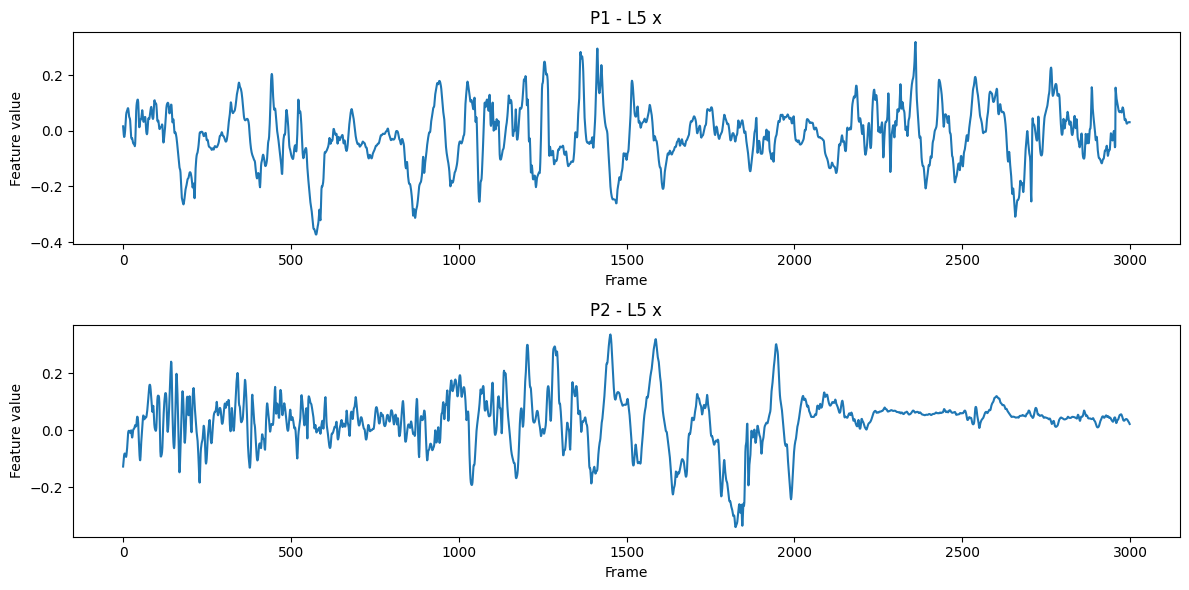

In [15]:
import matplotlib.pyplot as plt

# choose feature to visualize
feature_name = "L5 x"   # change to any feature column

# optionally select one video from each dataset
p1_sample = p1_df[p1_df["activity_type"] == "boning"].reset_index(drop=True)
p2_sample = p2_df[p2_df["activity_type"] == "boning"].reset_index(drop=True)

# take first 3000 frames
p1_sample = p1_sample.iloc[:3000]
p2_sample = p2_sample.iloc[:3000]


# frame index
x1 = range(len(p1_sample))
x2 = range(len(p2_sample))

# create horizontal stacked plots
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# P1 plot
axes[0].plot(x1, p1_sample[feature_name])
axes[0].set_title(f"P1 - {feature_name}")
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Feature value")

# P2 plot
axes[1].plot(x2, p2_sample[feature_name])
axes[1].set_title(f"P2 - {feature_name}")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Feature value")

plt.tight_layout()
plt.show()

# process data

In [4]:
print("[phase=split] splitting P1 by video_id with stratified labels")
feature_cols = get_feature_columns(p1_df)
print(f"[phase=features] feature_cols={len(feature_cols)}")
print(feature_cols)

# Build per-video labels for stratification
video_label_map = (
    p1_df.groupby("video_id")["activity_type"]
    .agg(lambda s: s.mode().iloc[0])
)

p1_video_ids = video_label_map.index.values
p1_video_labels = video_label_map.values

train_vids, val_vids = train_test_split(
    p1_video_ids,
    test_size=val_split,
    random_state=seed,
    stratify=p1_video_labels,
)

train_df = p1_df[p1_df["video_id"].isin(train_vids)].copy()
val_df = p1_df[p1_df["video_id"].isin(val_vids)].copy()
test_df = p2_df.copy()

print(f"[phase=split] train_videos={len(train_vids)} val_videos={len(val_vids)}")

# Label proportions check (video-level)
from collections import Counter
print("[phase=split] label proportion (train videos)", Counter(video_label_map.loc[train_vids]))
print("[phase=split] label proportion (val videos)", Counter(video_label_map.loc[val_vids]))


[phase=split] splitting P1 by video_id with stratified labels
[phase=features] feature_cols=66
['L5 x', 'L5 y', 'L5 z', 'L3 x', 'L3 y', 'L3 z', 'T12 x', 'T12 y', 'T12 z', 'T8 x', 'T8 y', 'T8 z', 'Neck x', 'Neck y', 'Neck z', 'Head x', 'Head y', 'Head z', 'Right Shoulder x', 'Right Shoulder y', 'Right Shoulder z', 'Right Upper Arm x', 'Right Upper Arm y', 'Right Upper Arm z', 'Right Forearm x', 'Right Forearm y', 'Right Forearm z', 'Right Hand x', 'Right Hand y', 'Right Hand z', 'Left Shoulder x', 'Left Shoulder y', 'Left Shoulder z', 'Left Upper Arm x', 'Left Upper Arm y', 'Left Upper Arm z', 'Left Forearm x', 'Left Forearm y', 'Left Forearm z', 'Left Hand x', 'Left Hand y', 'Left Hand z', 'Right Upper Leg x', 'Right Upper Leg y', 'Right Upper Leg z', 'Right Lower Leg x', 'Right Lower Leg y', 'Right Lower Leg z', 'Right Foot x', 'Right Foot y', 'Right Foot z', 'Right Toe x', 'Right Toe y', 'Right Toe z', 'Left Upper Leg x', 'Left Upper Leg y', 'Left Upper Leg z', 'Left Lower Leg x', 'L

# get train test

In [5]:
print("[phase=preprocess] windowing + scaling")
X_train, y_train = create_windows(train_df, feature_cols, window_size, stride)
X_val, y_val = create_windows(val_df, feature_cols, window_size, stride)
X_test, y_test = create_windows(test_df, feature_cols, window_size, stride)

X_train = clean_features(X_train)
X_val = clean_features(X_val)
X_test = clean_features(X_test)

X_train, scaler = normalize_features(X_train)
X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)
y_test = encoder.transform(y_test)

train_dataset = MotionDataset(X_train, y_train)
val_dataset = MotionDataset(X_val, y_val)
test_dataset = MotionDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

print(
    f"[phase=dataset] train_samples={len(train_dataset)} val_samples={len(val_dataset)} "
    f"test_samples(P2)={len(test_dataset)}"
)


[phase=preprocess] windowing + scaling
[phase=dataset] train_samples=6313 val_samples=2566 test_samples(P2)=8761


In [6]:
print("[phase=model] build BiLSTM")
model = BiLSTM(
    input_size=X_train.shape[2],
    hidden_size=hidden_size,
    num_classes=len(encoder.classes_),
    num_layers=num_layers,
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
)

criterion, mode = build_loss(loss_cfg, len(encoder.classes_))

print(model)


[phase=model] build BiLSTM
BiLSTM(
  (lstm): LSTM(66, 128, num_layers=2, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc_out): Linear(in_features=128, out_features=1, bias=True)
  (dropout): Dropout(p=0.0, inplace=False)
  (relu): ReLU()
)


In [7]:
print("[phase=train] training")
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        grad_clip=grad_clip,
        mode=mode,
    )

    val_loss, val_acc = eval_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        mode=mode,
    )

    print(
        f"[{epoch+1}/{epochs}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )


[phase=train] training
[1/30] train_loss=0.5219 train_acc=0.7367 val_loss=0.3301 val_acc=0.9005
[2/30] train_loss=0.1933 train_acc=0.9314 val_loss=0.2121 val_acc=0.9344
[3/30] train_loss=0.1144 train_acc=0.9613 val_loss=0.2406 val_acc=0.9333
[4/30] train_loss=0.0852 train_acc=0.9704 val_loss=0.2464 val_acc=0.9128
[5/30] train_loss=0.0690 train_acc=0.9762 val_loss=0.2518 val_acc=0.9392
[6/30] train_loss=0.0534 train_acc=0.9823 val_loss=0.2292 val_acc=0.9457
[7/30] train_loss=0.0519 train_acc=0.9844 val_loss=0.2362 val_acc=0.9500
[8/30] train_loss=0.0443 train_acc=0.9867 val_loss=0.2458 val_acc=0.9438
[9/30] train_loss=0.0305 train_acc=0.9901 val_loss=0.2644 val_acc=0.9453
[10/30] train_loss=0.0328 train_acc=0.9888 val_loss=0.4758 val_acc=0.9219
[11/30] train_loss=0.0274 train_acc=0.9913 val_loss=0.3050 val_acc=0.9457
[12/30] train_loss=0.0201 train_acc=0.9949 val_loss=0.3105 val_acc=0.9474
[13/30] train_loss=0.0165 train_acc=0.9953 val_loss=0.3266 val_acc=0.9496
[14/30] train_loss=0.015

KeyboardInterrupt: 

In [37]:
print("[phase=evaluate] testing on P2")
test_loss, test_acc = eval_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    mode=mode,
)

print(f"[test] loss={test_loss:.4f} acc={test_acc:.4f}")


[phase=evaluate] testing on P2
[test] loss=2.2717 acc=0.7520
